In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [ ]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [ ]:
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:\n{df.head()}")

Shape: (1170, 6)

Columns:
['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']

Data Types:
Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

First 5 Rows:
                Date  Children apprehended and placed in CBP custody*  \
0  December 21, 2025                                              6.0   
1  December 18, 2025                                             11.0   
2  December 17, 2025                                              7.0   
3  December 16, 2025                                              8.0   
4  December 15, 2025 

In [ ]:
print("NULL VALUE ANALYSIS")
print(df.isnull().sum())

NULL VALUE ANALYSIS
Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [ ]:
df = df.dropna(subset=['Date'])
print(f"\nRows after dropping nulls: {len(df)}")


Rows after dropping nulls: 720


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')

# Rename columns for easier use
df.columns = ['date', 'apprehended', 'cbp_custody', 'transferred', 'hhs_care', 'discharged']
df = df.sort_values('date').reset_index(drop=True)

print("AFTER TYPE FIXES")
print(df.dtypes)

AFTER TYPE FIXES
date           datetime64[ns]
apprehended           float64
cbp_custody           float64
transferred           float64
hhs_care                int64
discharged            float64
dtype: object


In [ ]:
print("DUPLICATE CHECK")
dupes = df.duplicated(subset=['date']).sum()
print(f"Duplicate dates found: {dupes}")

DUPLICATE CHECK
Duplicate dates found: 0


In [ ]:
print("DATE GAP ANALYSIS")
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = full_range.difference(df['date'])

print(f"Total calendar days in range : {len(full_range)}")
print(f"Days with actual data        : {len(df)}")
print(f"Missing days (gaps)          : {len(missing_dates)}")

missing_series = pd.Series(missing_dates)
print(f"\nMissing days by day of week:")
print(missing_series.dt.day_name().value_counts())

DATE GAP ANALYSIS
Total calendar days in range : 1075
Days with actual data        : 720
Missing days (gaps)          : 355

Missing days by day of week:
Saturday     154
Friday       152
Sunday        24
Monday         8
Thursday       7
Wednesday      6
Tuesday        4
Name: count, dtype: int64


In [ ]:
print("TIME-SERIES PREPARATION")
# If 'date' is already the index, reset it to make it a column again for set_index to work without error
if df.index.name == 'date':
    df = df.reset_index()

df = df.set_index('date')
df = df.reindex(full_range)
df.index.name = 'date'

# Stock columns — carry forward (care load doesn't reset overnight)
stock_cols = ['hhs_care', 'cbp_custody']
df[stock_cols] = df[stock_cols].ffill()

# Flow columns — linear interpolation (daily counts, smooth fill)
flow_cols = ['apprehended', 'transferred', 'discharged']
df[flow_cols] = df[flow_cols].interpolate(method='linear')

df = df.reset_index()
print(f"Reindexed to full daily calendar: {len(df)} records")
print(f"Stock columns forward-filled     : {stock_cols}")
print(f"Flow columns interpolated        : {flow_cols}")
print(f"Remaining nulls:\n{df.isnull().sum()}")

TIME-SERIES PREPARATION
Reindexed to full daily calendar: 1075 records
Stock columns forward-filled     : ['hhs_care', 'cbp_custody']
Flow columns interpolated        : ['apprehended', 'transferred', 'discharged']
Remaining nulls:
date           0
apprehended    0
cbp_custody    0
transferred    0
hhs_care       0
discharged     0
dtype: int64


In [ ]:
print("ZERO / NEGATIVE VALUE CHECK")
numeric_cols = ['apprehended', 'cbp_custody', 'transferred', 'hhs_care', 'discharged']
for col in numeric_cols:
    zeros = (df[col] <= 0).sum()
    print(f"  {col}: {zeros} zero or negative values")


ZERO / NEGATIVE VALUE CHECK
  apprehended: 2 zero or negative values
  cbp_custody: 0 zero or negative values
  transferred: 3 zero or negative values
  hhs_care: 0 zero or negative values
  discharged: 1 zero or negative values


In [ ]:
print("OUTLIER CHECK (IQR METHOD)")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers | range [{df[col].min():.0f} - {df[col].max():.0f}]")


OUTLIER CHECK (IQR METHOD)
  apprehended: 0 outliers | range [0 - 333]
  cbp_custody: 0 outliers | range [7 - 531]
  transferred: 0 outliers | range [0 - 440]
  hhs_care: 0 outliers | range [1972 - 11516]
  discharged: 0 outliers | range [0 - 505]


In [ ]:
print("DESCRIPTIVE STATISTICS (CLEANED DATASET)")
print(df[numeric_cols].describe().round(1).to_string())

DESCRIPTIVE STATISTICS (CLEANED DATASET)
       apprehended  cbp_custody  transferred  hhs_care  discharged
count       1075.0       1075.0       1075.0    1075.0      1075.0
mean          92.0        169.5        127.9    6081.3       182.7
std           71.4        125.7         97.3    2838.8       131.3
min            0.0          7.0          0.0    1972.0         0.0
25%           12.0         36.0         14.3    2473.0        19.8
50%           99.7        189.0        157.0    6448.0       191.0
75%          144.5        259.0        196.8    8029.5       286.0
max          333.0        531.0        440.0   11516.0       505.0


In [ ]:
print("FEATURE ENGINEERING")
# --- Flow-Based Signal ---
df['net_flow'] = df['transferred'] - df['discharged']
print("net_flow = transferred - discharged  ✓")

# --- Lag Features ---
for lag in [1, 7, 14]:
    df[f'hhs_care_lag{lag}']    = df['hhs_care'].shift(lag)
    df[f'transferred_lag{lag}'] = df['transferred'].shift(lag)
    df[f'discharged_lag{lag}']  = df['discharged'].shift(lag)
print("Lag features created: t-1, t-7, t-14 for hhs_care, transferred, discharged  ✓")

# --- Rolling Statistics ---
for window in [7, 14]:
    df[f'hhs_care_rollmean{window}'] = df['hhs_care'].rolling(window).mean()
    df[f'hhs_care_rollstd{window}']  = df['hhs_care'].rolling(window).std()
    df[f'net_flow_rollmean{window}']  = df['net_flow'].rolling(window).mean()
print("Rolling mean & std created: 7-day and 14-day windows  ✓")

# --- Calendar Effects ---
df['day_of_week']  = df['date'].dt.dayofweek          # 0=Monday, 6=Sunday
df['day_name']     = df['date'].dt.day_name()
df['month']        = df['date'].dt.month
df['month_name']   = df['date'].dt.month_name()
df['quarter']      = df['date'].dt.quarter
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Holiday proxy — US federal holidays (approx months with known low activity)
federal_holiday_months = [1, 7, 11, 12]
df['is_holiday_month'] = df['month'].isin(federal_holiday_months).astype(int)

print("Calendar features created: day_of_week, month, quarter, is_weekend, week_of_year, is_holiday_month  ✓")

# Summary of all engineered features
feature_cols = [c for c in df.columns if c not in ['date'] + numeric_cols]
print(f"\nTotal engineered features: {len(feature_cols)}")
print(f"Feature list:\n{feature_cols}")

# Drop rows with NaN from lag/rolling (first 14 rows)
df_model = df.dropna().reset_index(drop=True)
print(f"\nRows before dropping lag NaNs : {len(df)}")
print(f"Rows after dropping lag NaNs  : {len(df_model)}")


FEATURE ENGINEERING
net_flow = transferred - discharged  ✓
Lag features created: t-1, t-7, t-14 for hhs_care, transferred, discharged  ✓
Rolling mean & std created: 7-day and 14-day windows  ✓
Calendar features created: day_of_week, month, quarter, is_weekend, week_of_year, is_holiday_month  ✓

Total engineered features: 24
Feature list:
['net_flow', 'hhs_care_lag1', 'transferred_lag1', 'discharged_lag1', 'hhs_care_lag7', 'transferred_lag7', 'discharged_lag7', 'hhs_care_lag14', 'transferred_lag14', 'discharged_lag14', 'hhs_care_rollmean7', 'hhs_care_rollstd7', 'net_flow_rollmean7', 'hhs_care_rollmean14', 'hhs_care_rollstd14', 'net_flow_rollmean14', 'day_of_week', 'day_name', 'month', 'month_name', 'quarter', 'is_weekend', 'week_of_year', 'is_holiday_month']

Rows before dropping lag NaNs : 1075
Rows after dropping lag NaNs  : 1061


In [ ]:
print("TIME-SERIES DECOMPOSITION (HHS Care Load)")
#Use the clean series with datetime index for decomposition
hhs_series = df.set_index('date')['hhs_care']

decomposition = seasonal_decompose(
    hhs_series,
    model='additive',
    period=30,       # ~monthly seasonality
    extrapolate_trend='freq'
)

print("Decomposition complete — additive model, period=30 days")
print(f"  Trend range   : {decomposition.trend.min():.0f} – {decomposition.trend.max():.0f}")
print(f"  Seasonal range: {decomposition.seasonal.min():.0f} – {decomposition.seasonal.max():.0f}")
print(f"  Residual range: {decomposition.resid.min():.0f} – {decomposition.resid.max():.0f}")


TIME-SERIES DECOMPOSITION (HHS Care Load)
Decomposition complete — additive model, period=30 days
  Trend range   : 1995 – 11117
  Seasonal range: -44 – 62
  Residual range: -887 – 661


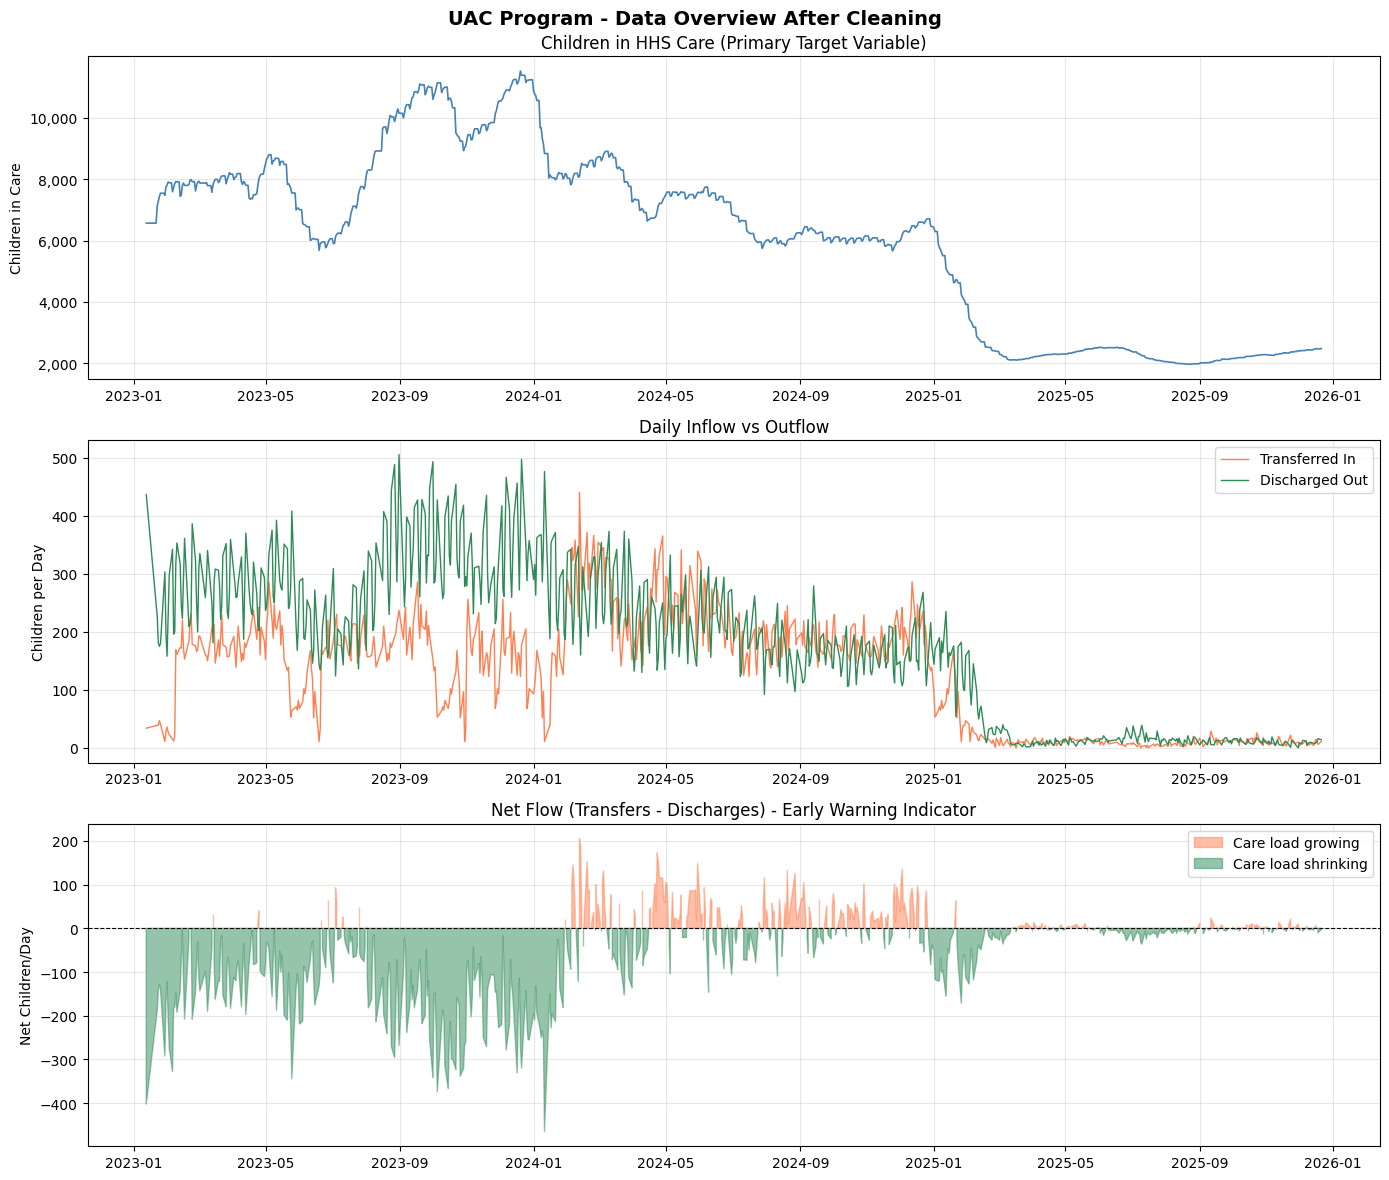

In [ ]:
# --- Plot A: Overview ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('UAC Program - Data Overview After Cleaning', fontsize=14, fontweight='bold')

axes[0].plot(df['date'], df['hhs_care'], color='steelblue', linewidth=1.2)
axes[0].set_title('Children in HHS Care (Primary Target Variable)')
axes[0].set_ylabel('Children in Care')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['transferred'], color='coral', linewidth=1, label='Transferred In')
axes[1].plot(df['date'], df['discharged'], color='seagreen', linewidth=1, label='Discharged Out')
axes[1].set_title('Daily Inflow vs Outflow')
axes[1].set_ylabel('Children per Day')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(df['date'], df['net_flow'], 0,
                     where=(df['net_flow'] > 0), color='coral', alpha=0.5, label='Care load growing')
axes[2].fill_between(df['date'], df['net_flow'], 0,
                     where=(df['net_flow'] <= 0), color='seagreen', alpha=0.5, label='Care load shrinking')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Net Flow (Transfers - Discharges) - Early Warning Indicator')
axes[2].set_ylabel('Net Children/Day')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


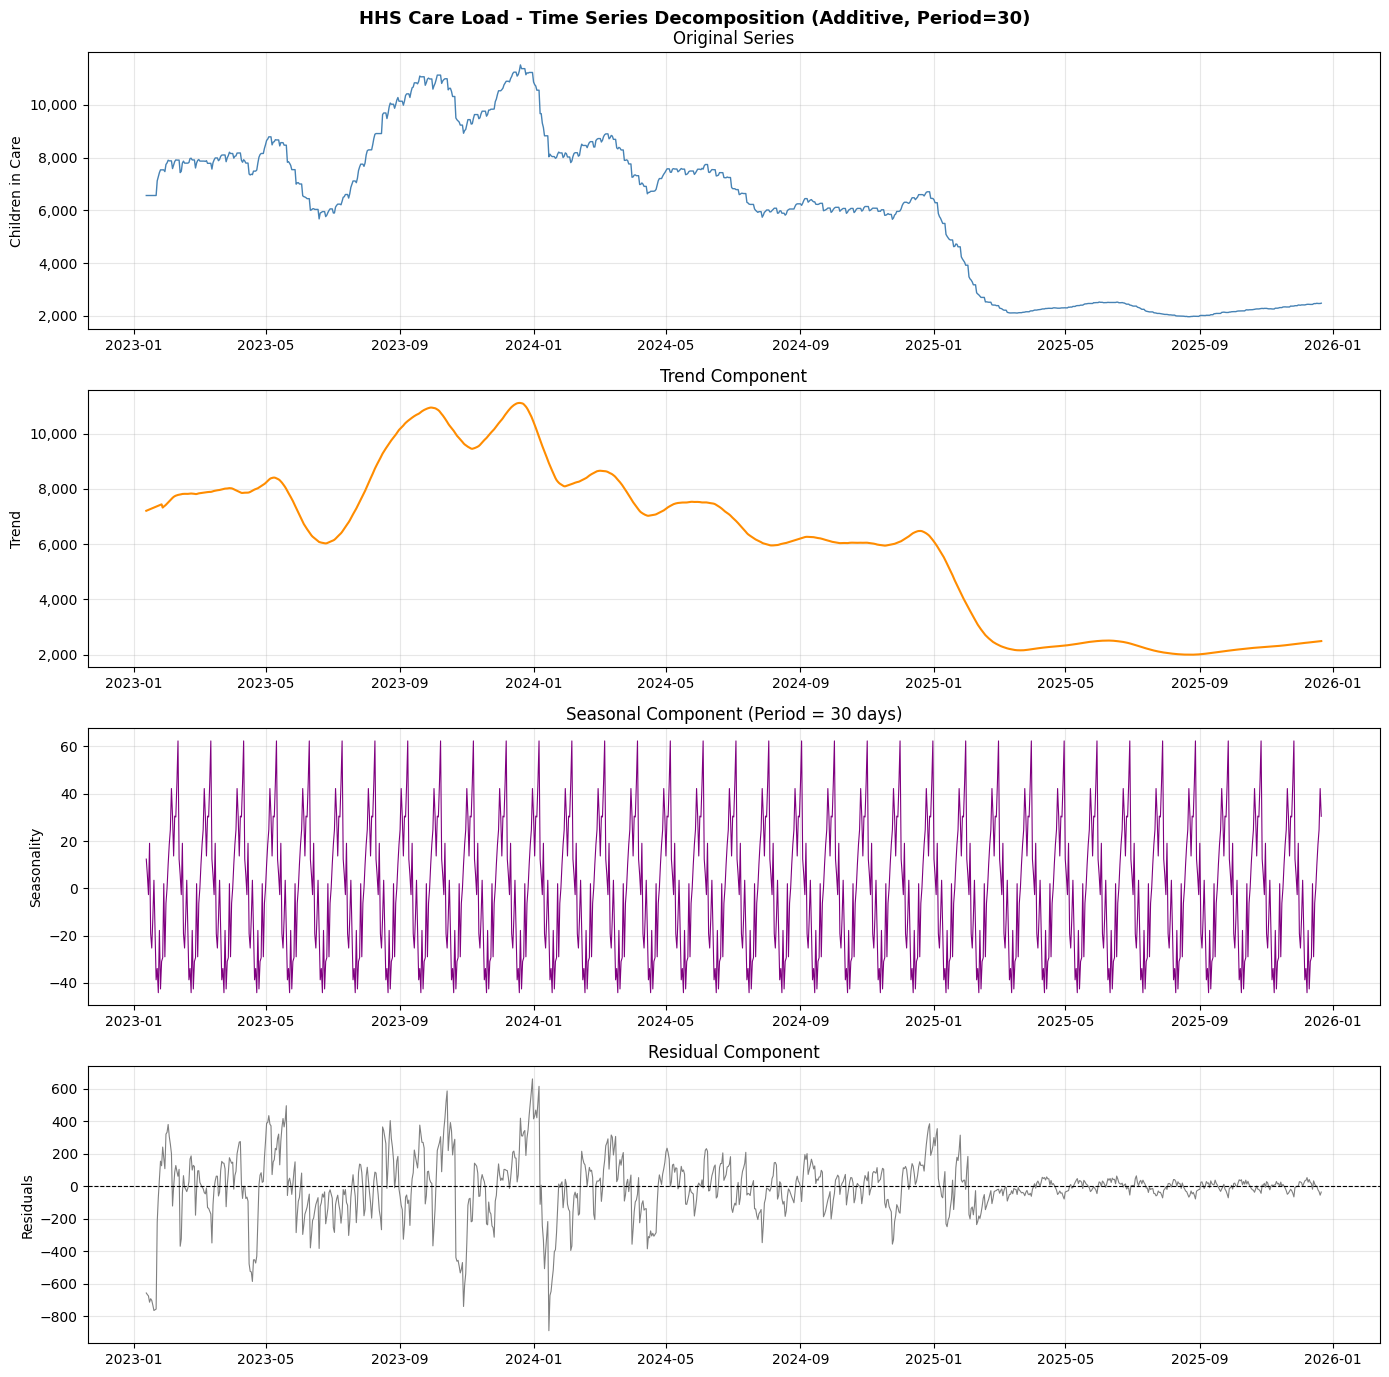

In [ ]:
# --- Plot B: Decomposition ---
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('HHS Care Load - Time Series Decomposition (Additive, Period=30)', fontsize=13, fontweight='bold')

axes[0].plot(hhs_series.index, hhs_series.values, color='steelblue', linewidth=1)
axes[0].set_title('Original Series')
axes[0].set_ylabel('Children in Care')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='darkorange', linewidth=1.5)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Trend')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='purple', linewidth=0.8)
axes[2].set_title('Seasonal Component (Period = 30 days)')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='gray', linewidth=0.8)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Residuals')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

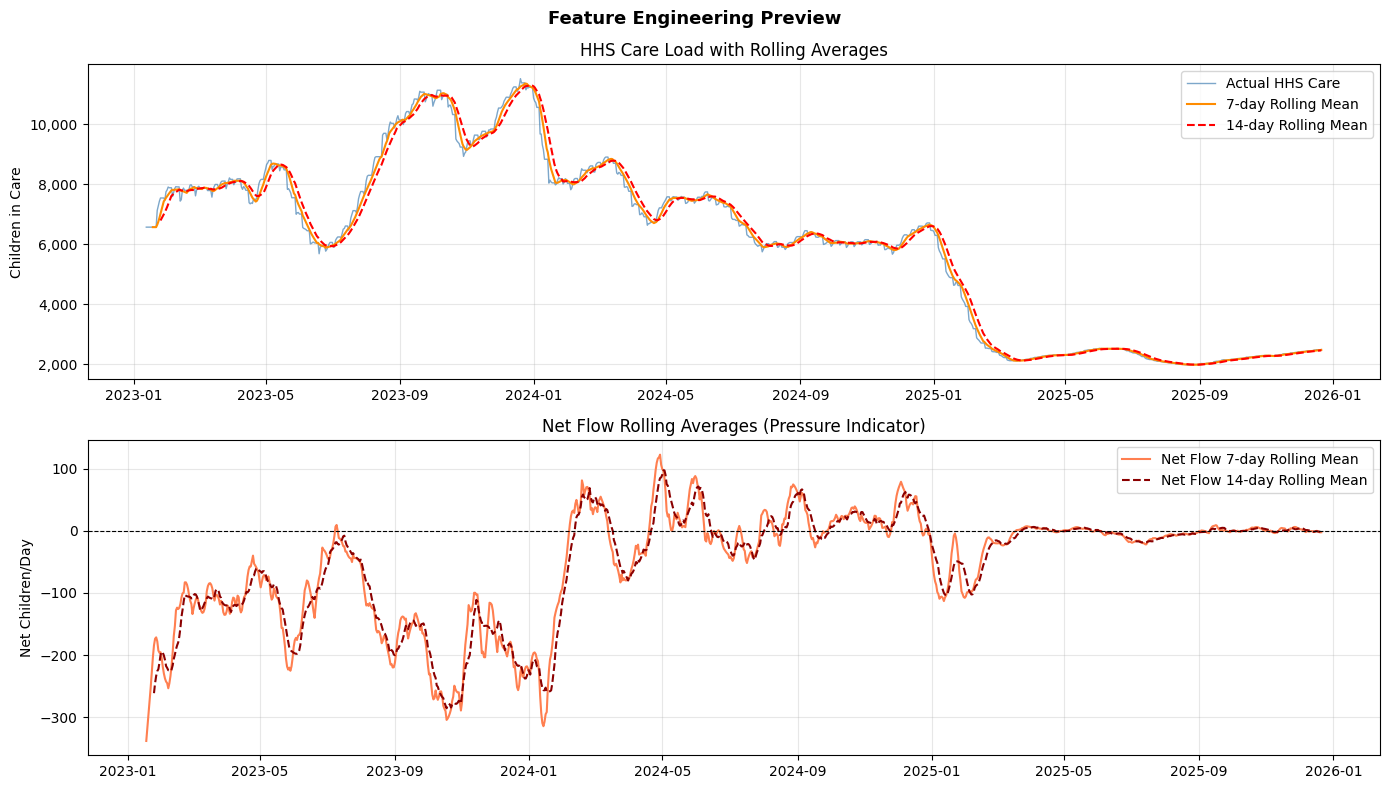

In [ ]:
# --- Plot C: Lag & Rolling Feature Preview ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Feature Engineering Preview', fontsize=13, fontweight='bold')

axes[0].plot(df['date'], df['hhs_care'], color='steelblue', linewidth=1, label='Actual HHS Care', alpha=0.7)
axes[0].plot(df['date'], df['hhs_care_rollmean7'], color='darkorange', linewidth=1.5, label='7-day Rolling Mean')
axes[0].plot(df['date'], df['hhs_care_rollmean14'], color='red', linewidth=1.5, linestyle='--', label='14-day Rolling Mean')
axes[0].set_title('HHS Care Load with Rolling Averages')
axes[0].set_ylabel('Children in Care')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['net_flow_rollmean7'], color='coral', linewidth=1.5, label='Net Flow 7-day Rolling Mean')
axes[1].plot(df['date'], df['net_flow_rollmean14'], color='darkred', linewidth=1.5, linestyle='--', label='Net Flow 14-day Rolling Mean')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Net Flow Rolling Averages (Pressure Indicator)')
axes[1].set_ylabel('Net Children/Day')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

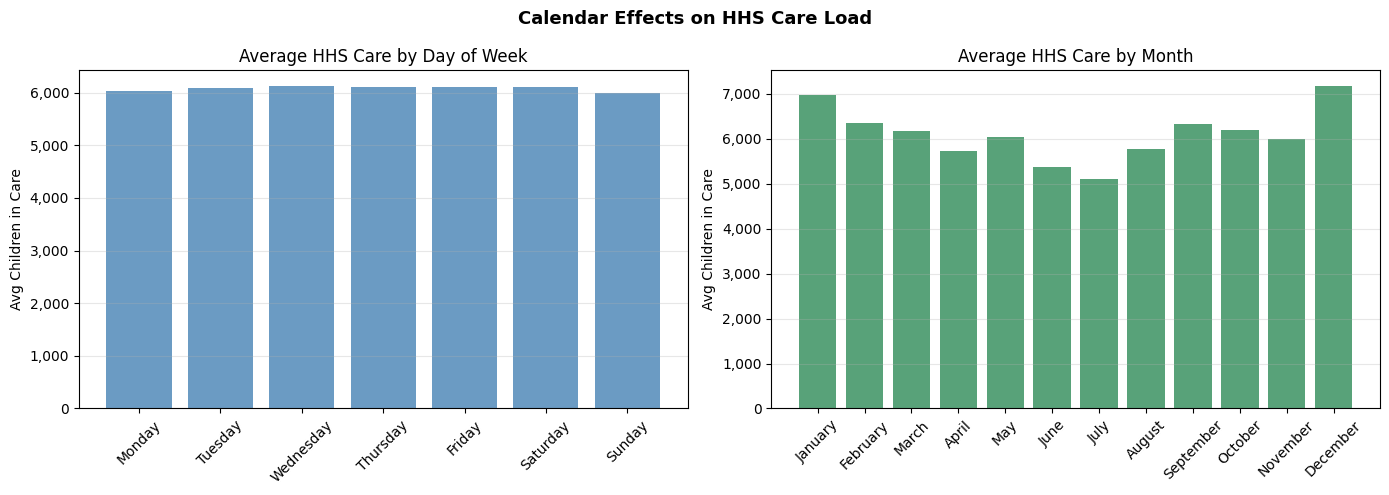

In [ ]:
# --- Plot D: Calendar Effects ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calendar Effects on HHS Care Load', fontsize=13, fontweight='bold')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = df.groupby('day_name')['hhs_care'].mean().reindex(day_order)
axes[0].bar(day_avg.index, day_avg.values, color='steelblue', alpha=0.8)
axes[0].set_title('Average HHS Care by Day of Week')
axes[0].set_ylabel('Avg Children in Care')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True, alpha=0.3, axis='y')

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_avg = df.groupby('month_name')['hhs_care'].mean().reindex(month_order)
axes[1].bar(month_avg.index, month_avg.values, color='seagreen', alpha=0.8)
axes[1].set_title('Average HHS Care by Month')
axes[1].set_ylabel('Avg Children in Care')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# STEP 2: TRAIN-TEST STRATEGY
# 2.1 STRICT TIME-BASED TRAIN/TEST SPLIT

# Sort by date to ensure strict temporal order
df_model = df_model.sort_values('date').reset_index(drop=True)

# 80% train / 20% test — no random sampling, strictly chronological
split_idx = int(len(df_model) * 0.80)

In [ ]:
train = df_model.iloc[:split_idx].copy()
test  = df_model.iloc[split_idx:].copy()

In [ ]:
print("TRAIN / TEST SPLIT (TIME-BASED)")
print(f"Total records     : {len(df_model)}")
print(f"Train size        : {len(train)} rows ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test size         : {len(test)}  rows ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Split date        : {test['date'].min().date()}")

TRAIN / TEST SPLIT (TIME-BASED)
Total records     : 1061
Train size        : 848 rows (2023-01-26 → 2025-05-22)
Test size         : 213  rows (2025-05-23 → 2025-12-21)
Split date        : 2025-05-23


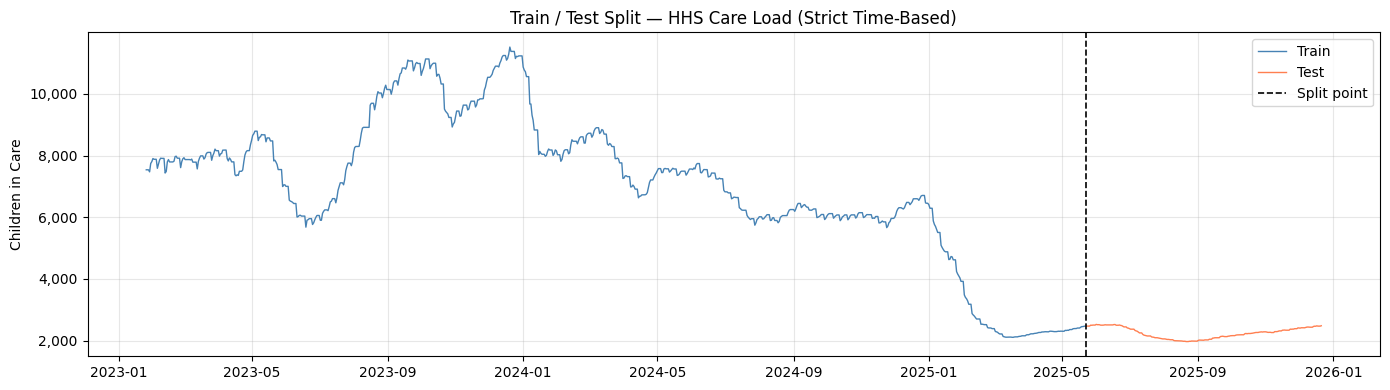

In [ ]:
# Visual check
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['date'], train['hhs_care'], color='steelblue', linewidth=1, label='Train')
ax.plot(test['date'],  test['hhs_care'],  color='coral',     linewidth=1, label='Test')
ax.axvline(x=test['date'].min(), color='black', linestyle='--', linewidth=1.2, label='Split point')
ax.set_title('Train / Test Split — HHS Care Load (Strict Time-Based)')
ax.set_ylabel('Children in Care')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2.2 WALK-FORWARD VALIDATION SETUP
print("WALK-FORWARD VALIDATION")
initial_train_size = int(len(df_model) * 0.60)   # start with 60% as initial window
horizon           = 7                              # forecast 7 days ahead per fold
step_size         = 7                             # slide forward 7 days each fold

folds = []
start = initial_train_size

while start + horizon <= len(df_model):
    fold_train = df_model.iloc[:start]
    fold_test  = df_model.iloc[start : start + horizon]
    folds.append({
        'fold'        : len(folds) + 1,
        'train_end'   : fold_train['date'].iloc[-1].date(),
        'test_start'  : fold_test['date'].iloc[0].date(),
        'test_end'    : fold_test['date'].iloc[-1].date(),
        'train_size'  : len(fold_train),
        'test_size'   : len(fold_test)
    })
    start += step_size

folds_df = pd.DataFrame(folds)
print(f"Initial training window : {initial_train_size} rows (60% of data)")
print(f"Forecast horizon        : {horizon} days per fold")
print(f"Step size               : {step_size} days")
print(f"Total folds generated   : {len(folds_df)}")
print(f"\nFirst 5 folds:")
print(folds_df.head().to_string(index=False))
print(f"\nLast 5 folds:")
print(folds_df.tail().to_string(index=False))

WALK-FORWARD VALIDATION
Initial training window : 636 rows (60% of data)
Forecast horizon        : 7 days per fold
Step size               : 7 days
Total folds generated   : 60

First 5 folds:
 fold  train_end test_start   test_end  train_size  test_size
    1 2024-10-22 2024-10-23 2024-10-29         636          7
    2 2024-10-29 2024-10-30 2024-11-05         643          7
    3 2024-11-05 2024-11-06 2024-11-12         650          7
    4 2024-11-12 2024-11-13 2024-11-19         657          7
    5 2024-11-19 2024-11-20 2024-11-26         664          7

Last 5 folds:
 fold  train_end test_start   test_end  train_size  test_size
   56 2025-11-11 2025-11-12 2025-11-18        1021          7
   57 2025-11-18 2025-11-19 2025-11-25        1028          7
   58 2025-11-25 2025-11-26 2025-12-02        1035          7
   59 2025-12-02 2025-12-03 2025-12-09        1042          7
   60 2025-12-09 2025-12-10 2025-12-16        1049          7


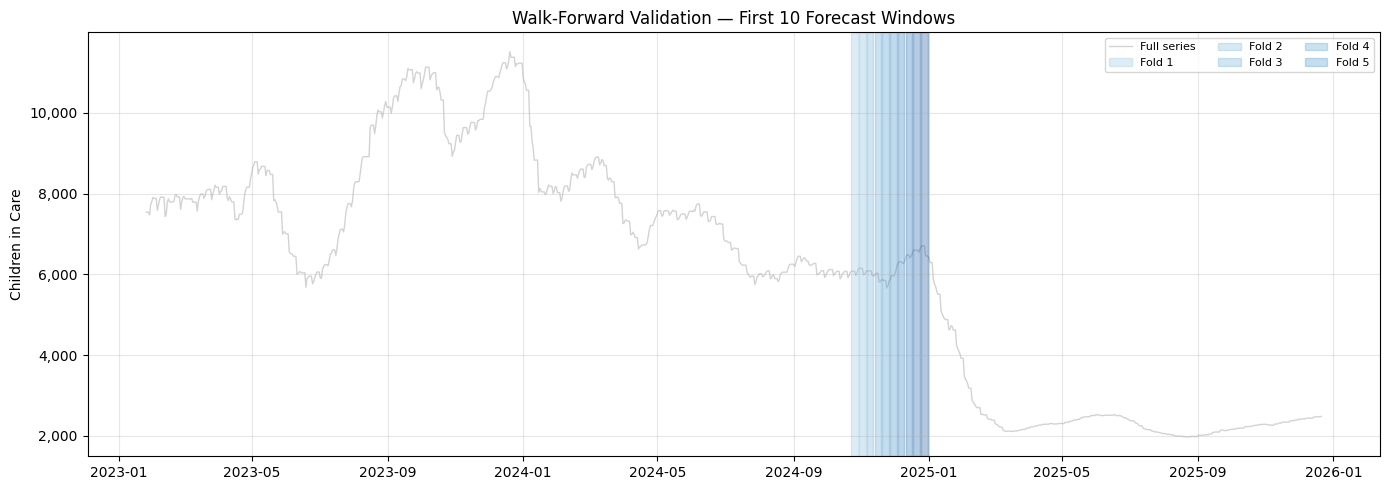

In [ ]:
# Visualise walk-forward folds (first 10 for clarity)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_model['date'], df_model['hhs_care'], color='lightgray', linewidth=1, label='Full series', zorder=1)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, min(10, len(folds))))
for i, fold in enumerate(folds[:10]):
    fold_test_data = df_model[
        (df_model['date'].dt.date >= fold['test_start']) &
        (df_model['date'].dt.date <= fold['test_end'])
    ]
    ax.axvspan(fold_test_data['date'].min(), fold_test_data['date'].max(),
               alpha=0.3, color=colors[i], label=f"Fold {fold['fold']}" if i < 5 else '')

ax.set_title('Walk-Forward Validation — First 10 Forecast Windows')
ax.set_ylabel('Children in Care')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2.3 MULTI-HORIZON EVALUATION SETUP
print("MULTI-HORIZON EVALUATION SETUP")
horizons = {
    'short_term'  : 7,
    'medium_term' : 14,
    'long_term'   : 30
}

horizon_windows = {}
for name, h in horizons.items():
    h_test = df_model.iloc[split_idx : split_idx + h].copy()
    horizon_windows[name] = h_test
    print(f"{name:15s} ({h:2d} days) : {h_test['date'].min().date()} → {h_test['date'].max().date()} | rows: {len(h_test)}")

# Evaluation metrics function — reusable across all models in later steps
def evaluate_forecast(actual, predicted, horizon_name=''):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae   = np.mean(np.abs(actual - predicted))
    rmse  = np.sqrt(np.mean((actual - predicted) ** 2))
    mape  = np.mean(np.abs((actual - predicted) / np.where(actual == 0, 1, actual))) * 100
    mase  = mae / np.mean(np.abs(np.diff(actual))) if len(actual) > 1 else np.nan
    r2    = 1 - np.sum((actual - predicted)**2) / np.sum((actual - np.mean(actual))**2)
    print(f"\n  Horizon: {horizon_name}")
    print(f"    MAE   : {mae:.2f}")
    print(f"    RMSE  : {rmse:.2f}")
    print(f"    MAPE  : {mape:.2f}%")
    print(f"    R²    : {r2:.4f}")
    return {'horizon': horizon_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MASE': mase, 'R2': r2}

print("\nEvaluation metrics function defined: MAE, RMSE, MAPE, MASE, R²")
print("Will be called in Steps 3+ after each model generates forecasts")


MULTI-HORIZON EVALUATION SETUP
short_term      ( 7 days) : 2025-05-23 → 2025-05-29 | rows: 7
medium_term     (14 days) : 2025-05-23 → 2025-06-05 | rows: 14
long_term       (30 days) : 2025-05-23 → 2025-06-21 | rows: 30

Evaluation metrics function defined: MAE, RMSE, MAPE, MASE, R²
Will be called in Steps 3+ after each model generates forecasts


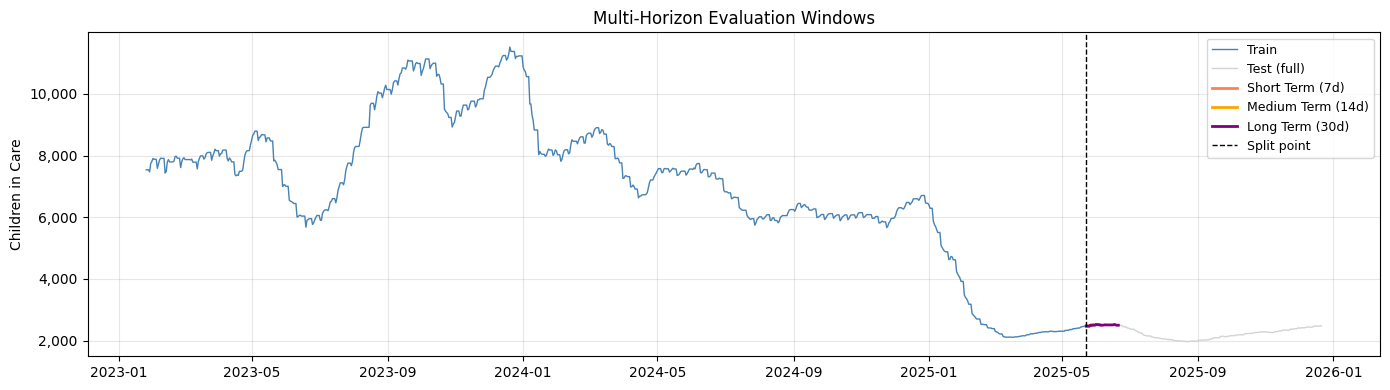

In [ ]:
# Visualise multi-horizon windows
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['date'], train['hhs_care'], color='steelblue', linewidth=1, label='Train')
ax.plot(test['date'],  test['hhs_care'],  color='lightgray', linewidth=1, label='Test (full)')

colors_h = {'short_term': 'coral', 'medium_term': 'orange', 'long_term': 'purple'}
for name, h_data in horizon_windows.items():
    ax.plot(h_data['date'], h_data['hhs_care'],
            color=colors_h[name], linewidth=2,
            label=f"{name.replace('_',' ').title()} ({horizons[name]}d)")

ax.axvline(x=test['date'].min(), color='black', linestyle='--', linewidth=1, label='Split point')
ax.set_title('Multi-Horizon Evaluation Windows')
ax.set_ylabel('Children in Care')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()